# Figure2: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure2/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `Figure_2a_b_clonal_mutation_counts` — resource-data sheet for the corresponding panel.
- `Figure_2c_expression_weighted_neoantigen_counts` — resource-data sheet for the corresponding panel.
- `Figure_2d_immune_editing_scores` — resource-data sheet for the corresponding panel.
- `Figure_2e_epithelial_tumor_normal_proportions` — resource-data sheet for the corresponding panel.
- `Figure_2f_epithelial_cluster_frequency_by_patient` — resource-data sheet for the corresponding panel.
- `Figure_2g_epithelial_marker_dotplot` — resource-data sheet for the corresponding panel.
- `Figure_2h_Gp1_Gp2_epithelial_proportions` — resource-data sheet for the corresponding panel.
- `Figure_2i_EK_HK_epithelial_cell_composition` — resource-data sheet for the corresponding panel.
- `Figure_2j_CellChat_filtered_interactions` — resource-data sheet for the corresponding panel.
- `Figure_2j_CellChat_network_edges` — resource-data sheet for the corresponding panel.
- `Figure_2k_ECGEA_logrank_statistics` — resource-data sheet for the corresponding panel.
- `Figure_2k_ECGEA_survival_marker_stratification` — resource-data sheet for the corresponding panel.
- `Figure_2l_Gp1_change_nonresponder_groups` — resource-data sheet for the corresponding panel.
- `Figure_2m_Treg_expanded_cell_proportions` — resource-data sheet for the corresponding panel.
- `Figure_2n_virus_detected_cell_percentages` — resource-data sheet for the corresponding panel.
- `Figure_2o_virus_detected_Gp1_Gp2_percentages` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [53]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


# Figure 2 plotting code\n\nOrganized copy of the manuscript plotting notebook. This standalone notebook runs from `code/`; inputs are in `../data/` and outputs are written to `../output/`. Large inputs are relative symbolic links, described in `../../data/DATA_INPUT_MANIFEST.tsv`.\n

# figure 2 vlz

- kernel: r_env, R 4.1.3
- date: 2023-12-27 ~ 12-28

## load

In [54]:
library(tidyverse)
library(tools)
if (requireNamespace("logging", quietly = TRUE)) { library(logging); logging::basicConfig() } else { loginfo <- function(...) invisible(NULL) }
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(Seurat)
if (requireNamespace("maftools", quietly = TRUE)) library(maftools)
library(ComplexHeatmap)
if (requireNamespace("CellChat", quietly = TRUE)) library(CellChat)

source('shared/r_funcs.r')

configure_panel_wilcox <- function(plot, ...) {
    stat_df <- panel_wilcox_stats(data = plot$data, ...)

    # stat_pvalue_manual() 的 y.position 需要与绘图坐标尺度一致
    plot_stat_df <- stat_df
    y_scale <- plot$scales$get_scales('y')

    if (!is.null(y_scale) && !is.null(y_scale$trans$transform)) {
        plot_stat_df$y.position <- y_scale$trans$transform(
            plot_stat_df$y.position
        )
    }

    configured_plot <- add_panel_wilcox(plot, plot_stat_df)

    # 表格中仍保留原始数据尺度的 y.position
    attr(configured_plot, 'panel_wilcox_stats') <- stat_df
    configured_plot
}


theme_set(theme_pubr())

options(warn = -1)

outdir <- "../output"
create_dir(outdir)

In [55]:
ctype_ls <- list(
    'Tumor_Gp1' = c("Epi_M_CALML3"),
    'Tumor_Gp2' = c("Epi_M_CPS1", "Epi_M_MYBPC1", "Epi_M_PKP2", "Epi_M_SPRR3", "Epi_M_ACTL8", 'Epi_M_RNASE1'),
    'Epi_Normal' = c("Epi_A_IL1R2", "Epi_A_MGP", "Epi_N_LTF", "Epi_N_PIGR"),
    'Mixture' = c('Epi_T_Mix', 'Epi_B_Mix')
)
epi_gp_order <- c('Tumor_Gp1', 'Tumor_Gp2', 'Epi_Normal', 'Mixture')

f_pat_gp <- '../data/Figure2/tables/patient_info.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

gp_lvls$response_v2 <- c('R', 'Gp1-', 'Gp1+', 'NR')
gp_comp_map$response_v2 <- list(
    c('R-pre', 'R-post'),
    c('Gp1+-pre', 'Gp1+-post'),
    c('Gp1--pre', 'Gp1--post'),
    c('R-pre', 'Gp1--pre'),
    c('R-post', 'Gp1--post'),
    c('Gp1+-pre', 'Gp1--pre'),
    c('Gp1+-post', 'Gp1--post'),
    c('R-pre', 'Gp1+-pre'),
    c('R-post', 'Gp1+-post')
)
gp_comp_diff_map$response_v2 <- list(
    c('R', 'Gp1+'),
    c('R', 'Gp1-'),
    c('Gp1+', 'Gp1-')
)
gp_comp_map_pre$response_v2 <- list(c('R-pre', 'Gp1--pre'),  c('R-pre', 'Gp1+-pre'), c('Gp1+-pre', 'Gp1--pre'))
comb_order_v2 <- c('R-pre', 'R-post', 'Gp1--pre', 'Gp1--post', 'Gp1+-pre', 'Gp1+-post', 'NR-pre')

## 2a-d: immune signature

- TMB: based on T-N paired, fresh, non-LN samples; mutation based on pyclone results (t_alt_count >= 3, t_depth >= 30, autosome mutations), CCF >= 50%
- TNB: sc & wes shared samples, tn-pair, fresh, nonLN samples

### 2a: CCF >= 50%, r vs nr at pre

In [56]:
f_tmb_ccf <- '../data/Figure2/stage4/a15_wes_clone_infer/new-pyclone/parse/tmb-by_ccf-0.5_1-tn_pair-fresh-t.tsv'
tmb <- read_tsv(f_tmb_ccf, show_col_types = F)
loginfo('%g mutations, %g samples', sum(tmb$n_mut_per_samp_ctype), length(unique(tmb$sample_id)))

2026-07-17 22:47:47.180375 INFO::5529 mutations, 53 samples


In [57]:
# ccf filtering (>=50% = middle)
tmb_flt <- filter(tmb, ccf_type == 'middle') %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient_id') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

write_tsv(tmb_flt, file = str_glue('{outdir}/fig2a-tmb-cff_gt_0.5-tn_pair-fresh-t.tsv'))

loginfo('ccf>=50%%, %g mutations, %g samples', sum(tmb_flt$n_mut_per_samp_ctype), length(unique(tmb_flt$sample_id)))

2026-07-17 22:47:47.904704 INFO::ccf>=50%, 4053 mutations, 53 samples


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 R-pre  NR-pre                1 FALSE     27    14      NA        272. 0.0242
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


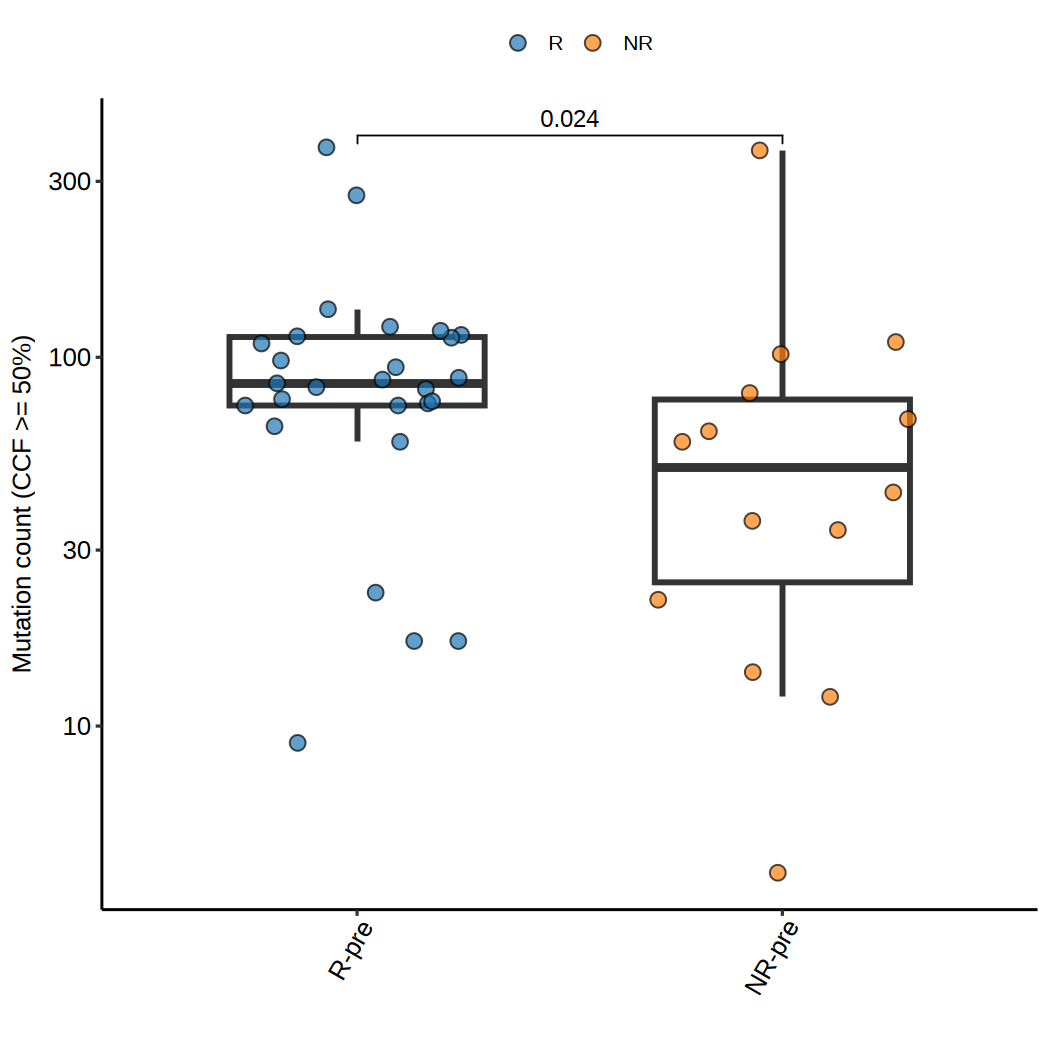

In [58]:

p <- tmb_flt %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    filter(sample_type == 'pre') %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'n_mut_per_samp_ctype', xorder = paste0(gp_lvls[[gp]], '-pre'),
                      pt_fill = gp, fill_order = gp_lvls[[gp]], pair_by = NULL, facet_by = NULL, xangle = 60) +
    scale_y_continuous(trans = 'log10')  +
    labs(fill = '', x = '', y = 'Mutation count (CCF >= 50%)')
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'n_mut_per_samp_ctype',
    comparisons = gp_comp_map_pre[[gp]],
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2a-box_tmb-ccf_gt_0.5-{gp}-pre-tn_pair-fresh-t.pdf'),
       plot = p, width = 2, height = 5)
# 在当前 notebook 中显示最后生成的图。
p


### 2b: CCF >= 50%, pre vs post

- 2023-12-28

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 pre    post                  1 FALSE     45     8      NA         301 0.00275
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


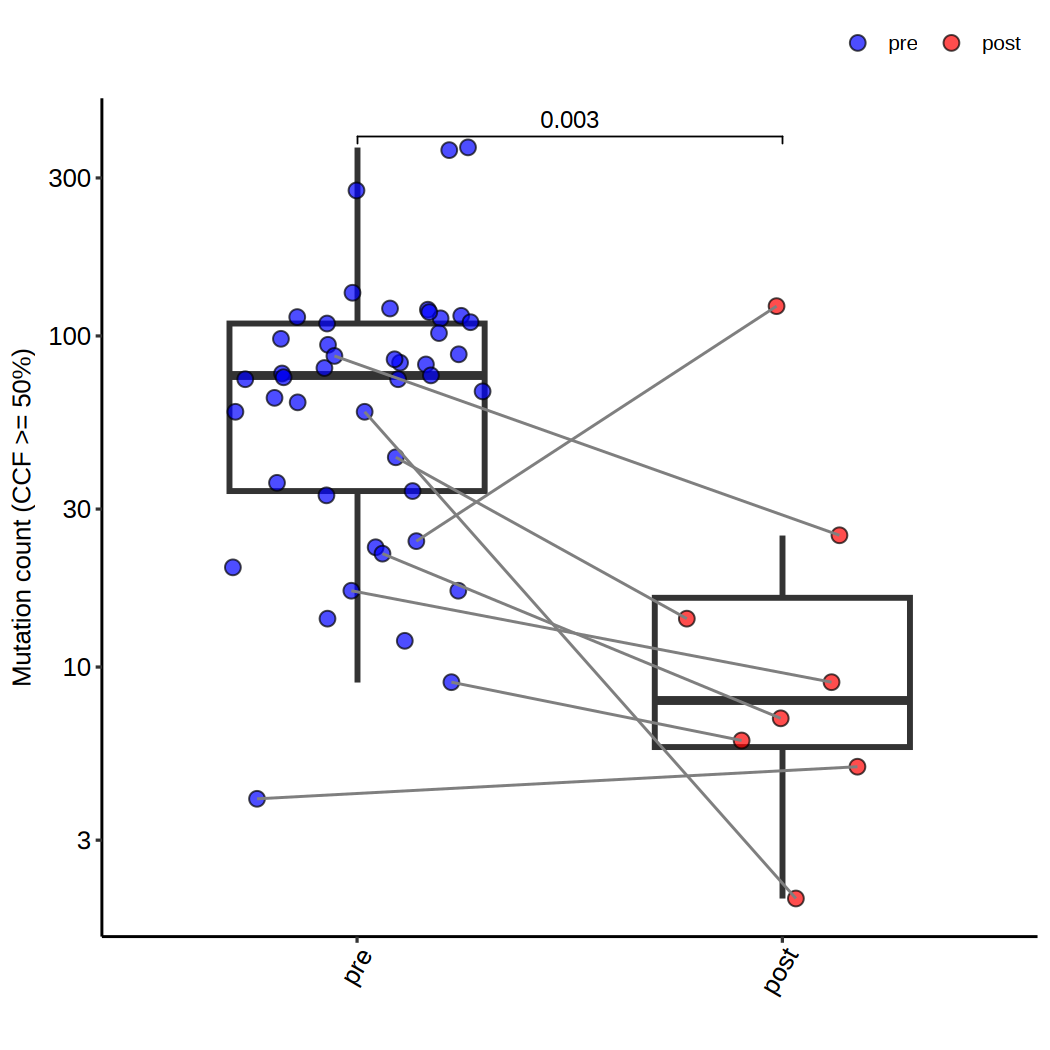

In [59]:

# by sample type
p <- read_tsv(file = str_glue('{outdir}/fig2a-tmb-cff_gt_0.5-tn_pair-fresh-t.tsv'), show_col_types = F) %>% 
    cell_comp_boxplot(x = 'sample_type', y = 'n_mut_per_samp_ctype', xorder = c('pre', 'post'),
                      pt_fill = 'sample_type', fill_order = c('pre', 'post'), pair_by = 'patient_id',
                      facet_by = NULL, xangle = 60) +
    scale_y_continuous(trans = 'log10')  +
    scale_fill_manual(values = c('pre' = 'blue', 'post' = 'red')) +
    labs(fill = '', x = '', y = 'Mutation count (CCF >= 50%)') +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'n_mut_per_samp_ctype',
    comparisons = list(c('pre', 'post')),
    use_paired = FALSE,
    pair_by = 'patient_id',
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2b-box_tmb-ccf_gt_0.5-pre_vs_post-tn_pair-fresh-t.pdf'),
       plot = p, width = 2, height = 5)
# 在当前 notebook 中显示最后生成的图。
p


### 2c: expression weighted neoantigen with CCF >= 50%

- desc: sc & wes shared samples, tn-pair, fresh, nonLN samples

In [60]:
f_wt_neo <- '../data/Figure2/stage4/a17_neoantigen/new-neo/analysis/mhc_i-neo_score-ccf-tn_pair-t-sc-exprs.tsv'
samp_clins <- c('patient_id', 'patient', 'treatment_group', 'sample_id', 'sample_type')

df <- read_tsv(f_wt_neo, show_col_types = F) %>% 
    filter(pair_cat == 'Fresh', pair_mode == 'tumor-normal-paired', !grepl('-LN', sample_id)) %>%
    filter(ccf >= 0.5) %>%
    select(all_of(c(samp_clins, 'purity', 'ploidy', 'seq', 'exprs'))) %>%
    distinct() %>%  # same peptide seq but recognized by >=1 HLA is consider only once
    count(pick(c(samp_clins, 'purity', 'ploidy')), name = 'wt_score', wt = .data[['exprs']]) %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient_id')


df %>% write_tsv(str_glue('{outdir}/fig2c-exprs_wt_tnb-ccf_gt_0.5-tn_pair-fresh-t.tsv'))
loginfo('tn_pair, fresh, nonLN: %g records, %g samples', nrow(df), length(unique(df$sample_id)))

2026-07-17 22:47:51.944371 INFO::tn_pair, fresh, nonLN: 33 records, 33 samples


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 R-pre  NR-pre                1 FALSE     17    11      NA         153 0.00414
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


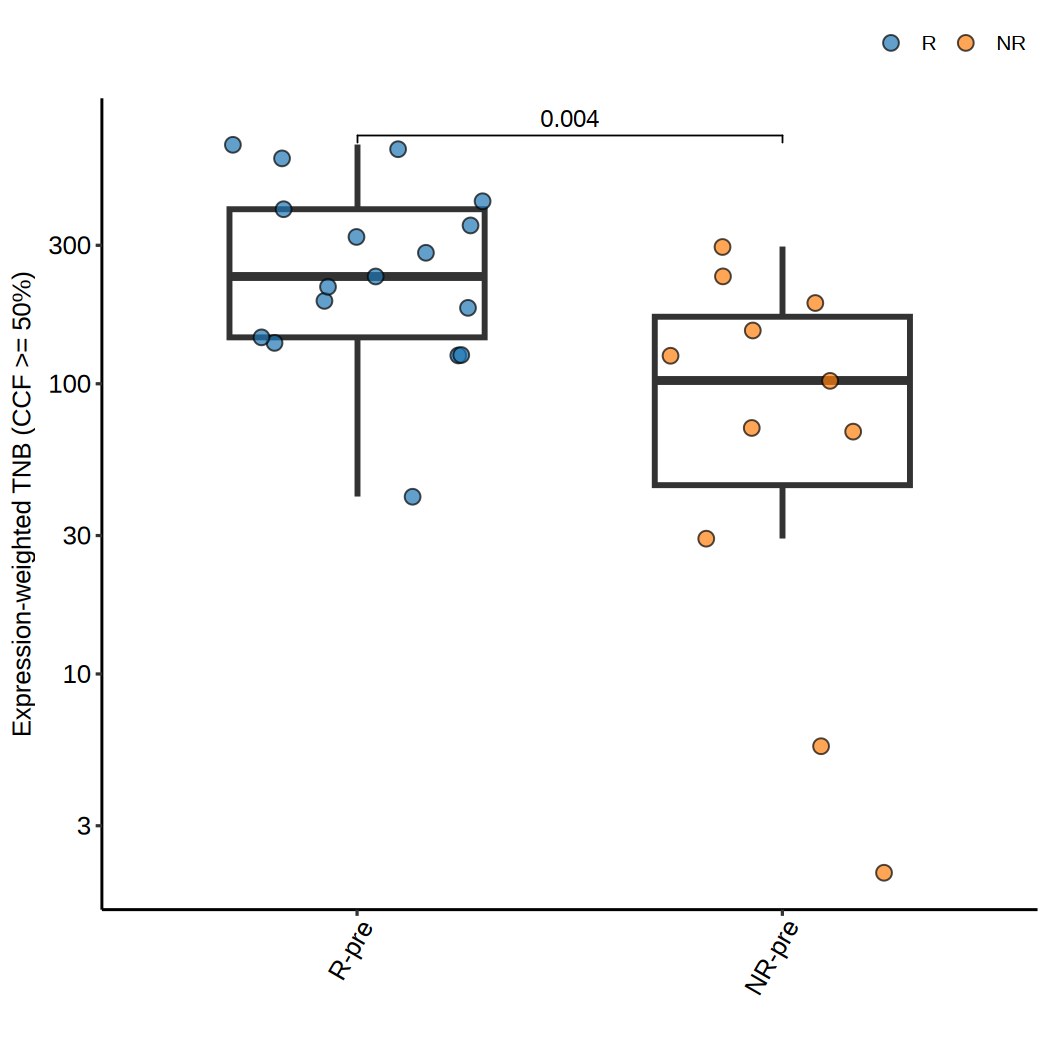

In [61]:

# mandard group at baseline
p <- read_tsv(file = str_glue('{outdir}/fig2c-exprs_wt_tnb-ccf_gt_0.5-tn_pair-fresh-t.tsv'), show_col_types = F) %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    filter(sample_type == 'pre') %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'wt_score', xorder = paste0(gp_lvls[[gp]], '-pre'),
                      pt_fill = gp, fill_order = gp_lvls[[gp]], pair_by = NULL,
                      facet_by = NULL, xangle = 60) +
    scale_y_continuous(trans = 'log10')  +
    labs(fill = '', x = '', y = 'Expression-weighted TNB (CCF >= 50%)') +
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'wt_score',
    comparisons = gp_comp_map_pre[[gp]],
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2c-box_wt_tnb-ccf_gt_0.5-{gp}-pre-tn_pair-fresh-t.pdf'),
       plot = p, width = 2, height = 5)
# 在当前 notebook 中显示最后生成的图。
p


### 2d: immune editing score

- desc: tn-pair, fresh, nonLN sample

In [62]:
f_edit_score <- '../data/Figure2/stage4/a11_wes/new-muts/immune_editing_score.tsv'

df <- read_tsv(f_edit_score, show_col_types = F) %>% 
    filter(!grepl('-LN', sample_id), pair_cat == 'Fresh', pair_mode == 'tumor-normal-paired') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient_id')

df %>% write_tsv(str_glue('{outdir}/fig2d-immune_editing_score-tn_pair-fresh-t.tsv'))
loginfo('tn_pair, fresh, nonLN: %g records, %g samples', nrow(df), length(unique(df$sample_id)))

2026-07-17 22:47:52.853636 INFO::tn_pair, fresh, nonLN: 53 records, 53 samples


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 pre    post                  1 FALSE     45     8      NA         286 0.00692
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


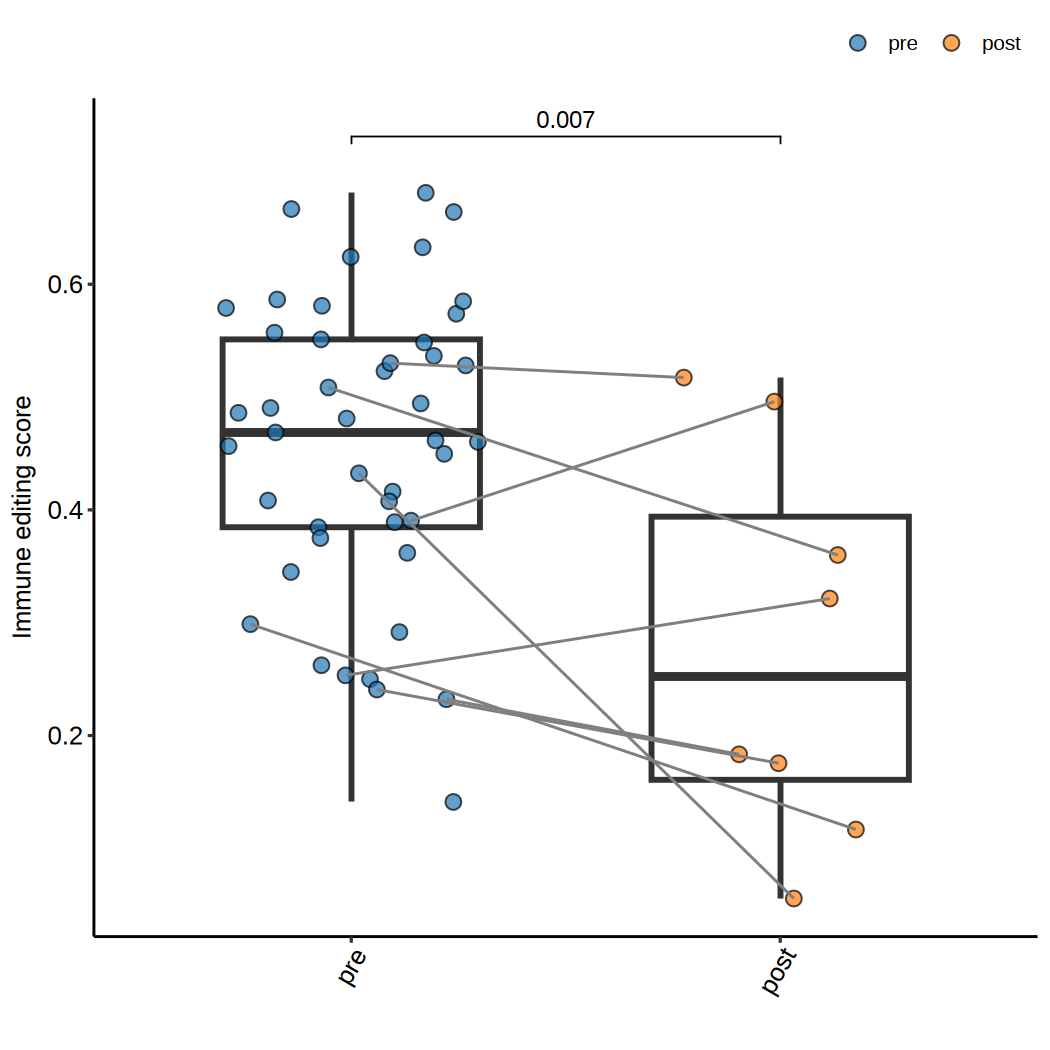

In [63]:

# pre vs post
p <- df %>% 
    cell_comp_boxplot(x = c('sample_type'), y = 'editing_score', pt_fill = 'sample_type', pair_by = 'patient_id',
                      fill_order = c('pre', 'post'), facet_by = NULL, xorder = c('pre', 'post'), xangle = 60) +
    labs(fill = '', y = 'Immune editing score') + 
    theme(legend.justification = c(1, 0))
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'editing_score',
    comparisons = list(c('pre', 'post')),
    use_paired = FALSE,
    pair_by = 'patient_id',
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2d-box_edit_score-pre_vs_post-tn_pair-fresh-t.pdf'),
       plot = p, width = 2, height = 4.5)
# 在当前 notebook 中显示最后生成的图。
p


## 2e: cell compostion for tumor/Normal Epi, min50 result

In [64]:
f_cc <- '../data/Figure2/figures/fig2/fig2i-cell_comp-ek_hk.tsv'
min_cell <- 50

In [65]:
df <- read_tsv(file = f_cc, show_col_types = F) %>% 
    mutate(cellgp = if_else(cell_type %in% c('Tumor_Gp1', 'Tumor_Gp2'), 'Tumor_Gp1/2', cell_type)) %>% 
    summarise(.by = c('patient', 'patient_id', 'response', 'sample_type', 'cellgp', 'n_cell_per_sample_ctype'),
             freq = sum(freq)) %>% 
    mutate(pct = 100 * freq / n_cell_per_sample_ctype)
df %>% write_tsv(str_glue('{outdir}/fig2e-epi-tumor_normal_cc.tsv'))

# A tibble: 8 × 14
  cellgp   group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W
  <fct>    <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>
1 Epi_Nor… R-pre  R-post                1 FALSE     22    19      NA        30  
2 Epi_Nor… NR-pre NR-po…                2 FALSE     16    13      NA        74  
3 Epi_Nor… R-pre  NR-pre                3 FALSE     22    16      NA       155  
4 Epi_Nor… R-post NR-po…                4 FALSE     19    13      NA       199  
5 Tumor_G… R-pre  R-post                1 FALSE     22    19      NA       403  
6 Tumor_G… NR-pre NR-po…                2 FALSE     16    13      NA        99  
7 Tumor_G… R-pre  NR-pre                3 FALSE     22    16      NA       219  
8 Tumor_G… R-post NR-po…                4 FALSE     19    13      NA        39.5
# ℹ 5 more variables: p_raw <dbl>, p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>
# A tibble: 8 × 14
  cellgp   group1 group2 comparison_order paired    n

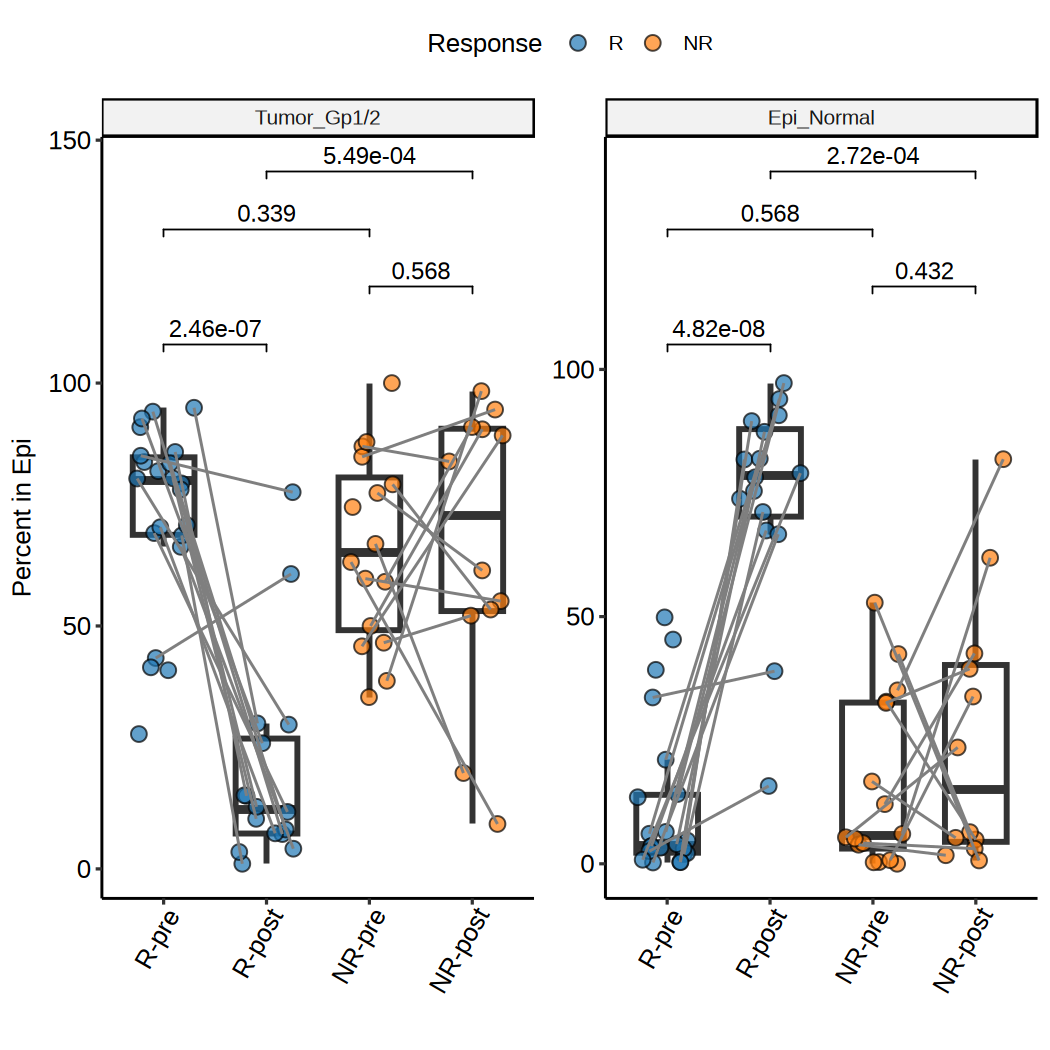

In [66]:

# for all samples
p <- read_tsv(str_glue('{outdir}/fig2e-epi-tumor_normal_cc.tsv'), show_col_types = F) %>% 
    filter(!is.na(.data[[gp]])) %>%
    filter(cellgp %in% c('Tumor_Gp1/2', 'Epi_Normal')) %>%
    mutate(cellgp = factor(cellgp, c('Tumor_Gp1/2', 'Epi_Normal'))) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, facet_by = 'cellgp',
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60)  +
    labs(y = 'Percent in Epi', fill = 'Response')
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'pct',
    comparisons = gp_comp_map[[gp]],
    facet_by = 'cellgp',
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2e-box_cc_in_epi-tumor_normal-all.pdf'), plot = p, width = 7, height = 5.5)

# filter out samples without enough cells
p <- read_tsv(str_glue('{outdir}/fig2e-epi-tumor_normal_cc.tsv'), show_col_types = F) %>% 
    filter(n_cell_per_sample_ctype >= min_cell) %>%
    filter(!is.na(.data[[gp]])) %>%
    filter(cellgp %in% c('Tumor_Gp1/2', 'Epi_Normal')) %>%
    mutate(cellgp = factor(cellgp, c('Tumor_Gp1/2', 'Epi_Normal'))) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, facet_by = 'cellgp',
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60)  +
    labs(y = 'Percent in Epi', fill = 'Response')
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'pct',
    comparisons = gp_comp_map[[gp]],
    facet_by = 'cellgp',
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2e-box_cc_in_epi-macrotype-tumor_normal-min{min_cell}.pdf'), plot = p, width = 7, height = 5.5)
# 在当前 notebook 中显示最后生成的图。
p


## 2f: heatmap of cluster vs patient/sample: min50 result

In [67]:
f_epi_obs <- '../data/Figure2/stage4/a01_data/h5ad/epi_obs.csv'
min_cell <- 50  # min cell per group

In [68]:
# detail & macro celltype map
celltype_map <- do.call(
    rbind.data.frame, 
    lapply(X = names(ctype_ls), FUN = function(nm) {
        data.frame(macrotype = nm, celltype = ctype_ls[[nm]])
    })
)

# color map
macrotype_color_map <- pal_nejm()(length(unique(celltype_map$macrotype)))
names(macrotype_color_map) <- unique(celltype_map$macrotype)

# data: cell level
df <- read_csv(f_epi_obs, show_col_types = F)

New names:
• `` -> `...1`


In [69]:
# by patient
cal_by <- 'patient'
all_cal_types <- unique(df[[cal_by]])
highconf_cal_types <- count(df, .data[[cal_by]]) %>%
    filter(n >= min_cell) %>%
    pull(.data[[cal_by]])
loginfo('%g/%g %s with enough cells', length(highconf_cal_types), length(all_cal_types), cal_by)

# plot data
mat <- df %>% 
    count(.data[[cal_by]], cell_type, name = 'freq') %>% 
    pivot_wider(id_cols = c('cell_type'), names_from = .data[[cal_by]],
                values_from = 'freq', values_fill = 0) %>% 
    mutate(across(all_of(all_cal_types), ~ 100*.x/sum(.x))) %>%
    column_to_rownames('cell_type')
mat <- mat[intersect(pull(celltype_map, 'celltype'), rownames(mat)), ]

2026-07-17 22:47:55.484283 INFO::51/52 patient with enough cells


In [70]:
# plot: only patients with >= min_cell cells
suf <- str_glue('min{min_cell}')
dp <- mat[, highconf_cal_types, drop = FALSE]

set.seed(123)

row_anno <- rowAnnotation(
    'Epithelial\ncell groups' = pull(
        celltype_map, 'macrotype', name = 'celltype'
    )[rownames(dp)],
    col = list(
        'Epithelial\ncell groups' = macrotype_color_map
    ),
    show_annotation_name = c(
        'Epithelial\ncell groups' = FALSE
    ),
    width = unit(1, 'cm'),
    na_col = 'gray50',
    annotation_legend_param = list(
        'Epithelial\ncell groups' = list(
            at = names(macrotype_color_map),
            labels = names(macrotype_color_map)
        )
    )
)

treat_heatmap <- function(mat, name, col_title = '', return_ht = FALSE, outfile = NULL, fig_size = c(9, 7), ...) {
    hp <- ComplexHeatmap::Heatmap(matrix = mat, name = name, row_names_side = 'left', show_column_names = FALSE, column_title = col_title, ...)
    if (is.null(outfile) || return_ht) return(hp)
    if (tools::file_ext(outfile) == 'pdf') {
        grDevices::pdf(outfile, width = fig_size[1], height = fig_size[2]); ComplexHeatmap::draw(hp); grDevices::dev.off()
    } else {
        grDevices::png(outfile, width = fig_size[1], height = fig_size[2], units = 'in', res = 300); ComplexHeatmap::draw(hp); grDevices::dev.off()
    }
    invisible(hp)
}

treat_heatmap(
    mat = dp,
    cluster_columns = FALSE,
    cluster_rows = FALSE,
    name = str_glue('Percent \nin {cal_by}'),
    row_names_gp = gpar(fontsize = 9),
    right_annotation = row_anno,
    fig_size = c(7, 2),
    outfile = str_glue(
        '{outdir}/fig2f-heat-macro_pct_in_{cal_by}-{suf}.pdf'
    )
)

## 2g: marker dotplot

In [71]:
f_fig2g <- '../data/Figure2/core_inputs/Figure_2g_epithelial_marker_dotplot.tsv'

In [72]:
# Directly load Source Data for the dotplot; Mixture is excluded as in the original Seurat plot.
dp_fig2g <- read_tsv(f_fig2g, show_col_types = FALSE)
ctype_lvl <- setdiff(epi_gp_order, 'Mixture')
markers <- list(
    'Epi' = c('EPCAM', 'KRT14', 'KRT15'),
    'Epi Develop' = c('KRT6B', 'LGALS7B', 'KRT16', 'LY6D', 'TP63', 'LAMB3'),
    'Immune Repress' = c('CD74', 'PTGES', 'S100P', 'RUNX3', 'TGFB1', 'CEACAM1', 'OAS1', 'HLA-E', 'CTSD'),
    'Apoptosis Repress' = c('MUC1', 'PTGS2', 'PINK1', 'BCL2L1', 'SOD2', 'CCT3', 'PARP1')
)
gene_order <- unlist(markers, use.names = FALSE)
dp_fig2g <- dp_fig2g %>% filter(cell_group %in% ctype_lvl, gene %in% gene_order) %>%
    mutate(cell_group = factor(cell_group, levels = ctype_lvl),
           gene = factor(gene, levels = gene_order),
           color_value = as.numeric(scale(mean_expression)), .by = gene)

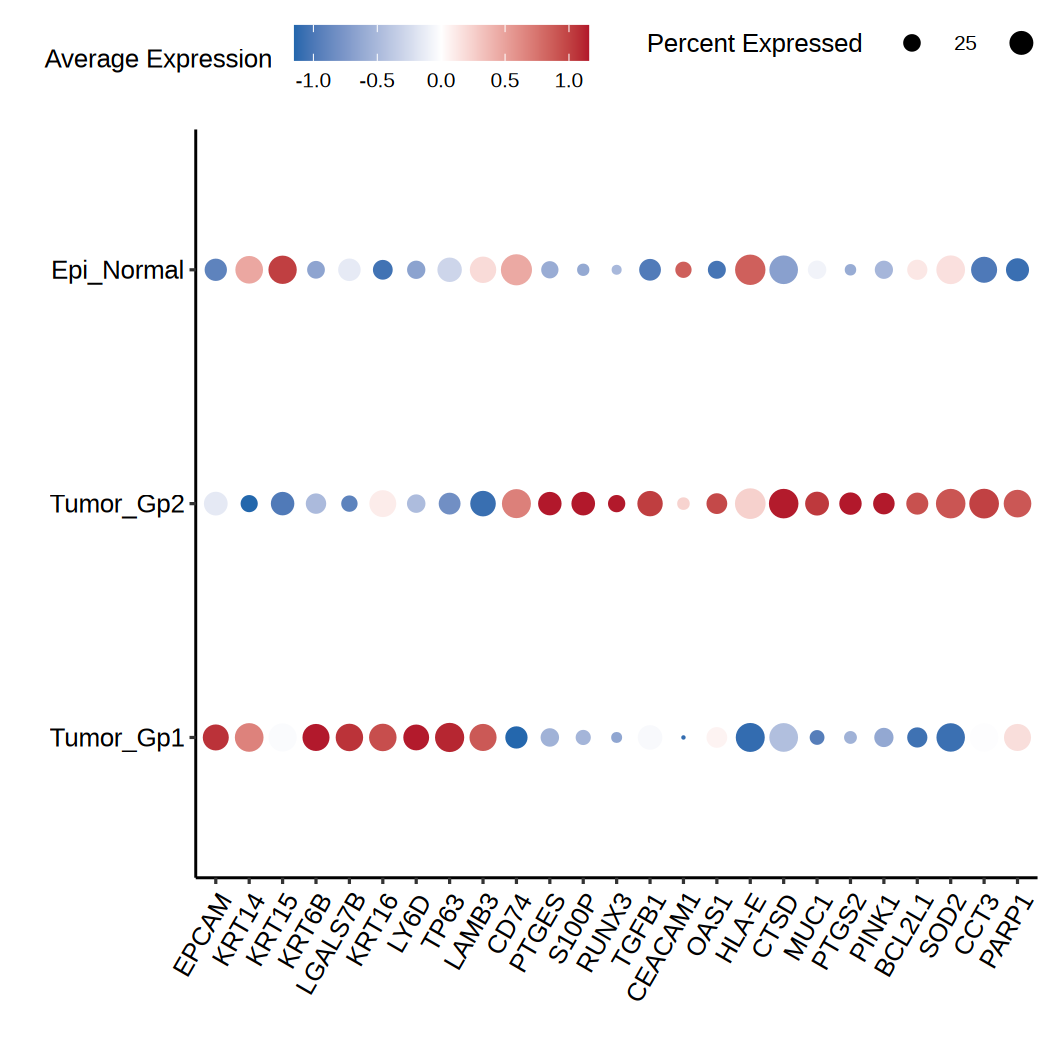

In [73]:
p <- ggplot(dp_fig2g, aes(x = gene, y = cell_group)) +
    geom_point(aes(size = percent_expressed, color = color_value)) +
    scale_size(range = c(0, 6), name = 'Percent Expressed') +
    scale_color_gradient2(low = '#2166AC', mid = 'white', high = '#B2182B', name = 'Average Expression') +
    labs(x = '', y = '') +
    theme(axis.text.x = element_text(angle = 60, hjust = 0.95, vjust = 0.95),
          legend.position = 'top', legend.title.align = 0.5, legend.justification = 0.5,
          legend.key.width = unit(1, 'cm'))
ggsave(filename = str_glue('{outdir}/fig2g-dot_epi_marker-noMixture.pdf'), plot = p, width = 9, height = 4)
# 在当前 notebook 中显示最后生成的图。
p


## 2h: macrotype by response: min50 result

In [74]:
f_fig2h <- '../data/Figure2/core_inputs/Figure_2h_Gp1_Gp2_epithelial_proportions.tsv'
min_cell <- 50

In [75]:
# Directly use the Figure 2h Source Data table; patient_id is added solely for downstream Figure 2i matching.
df <- read_tsv(f_fig2h, show_col_types = FALSE) %>%
    add_clin_info(ftsv = f_pat_gp, columns = 'patient_id', merge_by = 'patient')
df %>% write_tsv(str_glue('{outdir}/fig2h-cell_comp-ek_hk.tsv'))

# A tibble: 12 × 14
   cell_type  group1 group2  comparison_order paired    n1    n2 n_pairs
   <fct>      <chr>  <chr>              <int> <lgl>  <int> <int>   <int>
 1 Epi_Normal R-pre  R-post                 1 FALSE     22    16      NA
 2 Epi_Normal NR-pre NR-post                2 FALSE     16    12      NA
 3 Epi_Normal R-pre  NR-pre                 3 FALSE     22    16      NA
 4 Epi_Normal R-post NR-post                4 FALSE     16    12      NA
 5 Tumor_Gp1  R-pre  R-post                 1 FALSE     22    16      NA
 6 Tumor_Gp1  NR-pre NR-post                2 FALSE     16    12      NA
 7 Tumor_Gp1  R-pre  NR-pre                 3 FALSE     22    16      NA
 8 Tumor_Gp1  R-post NR-post                4 FALSE     16    12      NA
 9 Tumor_Gp2  R-pre  R-post                 1 FALSE     22    16      NA
10 Tumor_Gp2  NR-pre NR-post                2 FALSE     16    12      NA
11 Tumor_Gp2  R-pre  NR-pre                 3 FALSE     22    16      NA
12 Tumor_Gp2  R-post NR-post   

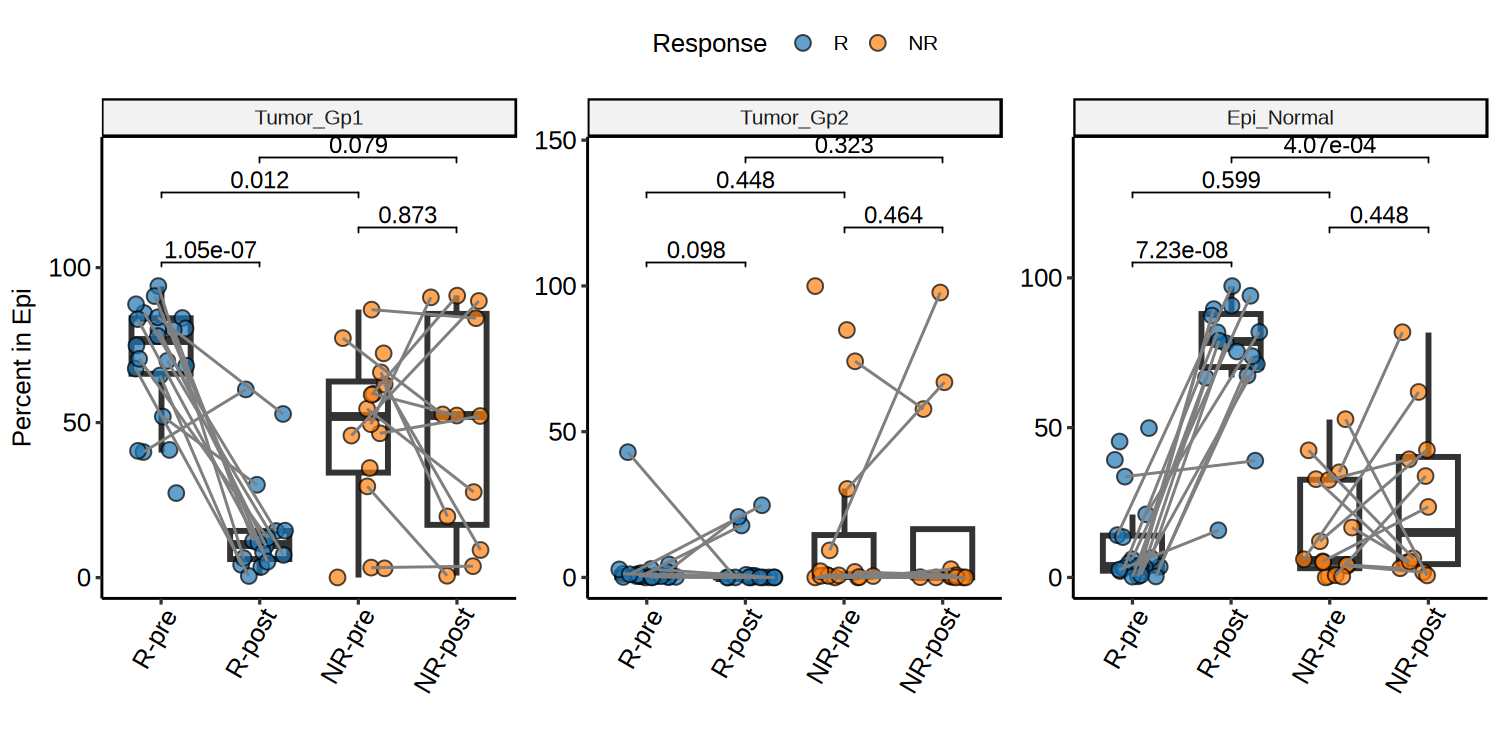

In [76]:

min_cell <- 50

plot_data <- read_tsv(
    str_glue('{outdir}/fig2h-cell_comp-ek_hk.tsv'),
    show_col_types = FALSE
) %>%
    filter(
        n_cell_per_sample_ctype >= min_cell,
        !is.na(.data[[gp]]),
        cell_type %in% c('Tumor_Gp1', 'Tumor_Gp2', 'Epi_Normal')
    ) %>%
    mutate(
        cell_type = factor(
            cell_type,
            levels = c('Tumor_Gp1', 'Tumor_Gp2', 'Epi_Normal')
        )
    )

p <- plot_data %>%
    cell_comp_boxplot(
        x = c(gp, 'sample_type'),
        y = 'pct',
        pt_fill = gp,
        xorder = comb_order,
        fill_order = gp_lvls[[gp]],
        xangle = 60
    ) +
    labs(
        y = 'Percent in Epi',
        fill = 'Response'
    )

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'pct',
    comparisons = gp_comp_map[[gp]],
    facet_by = 'cell_type',
    use_paired = FALSE,
    pair_by = 'patient',
    paired_comparisons = list(
        c('R-pre', 'R-post'),
        c('NR-pre', 'NR-post')
    ),
    apply_correction = TRUE,
    correction_method = 'BH'
)

panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue(
        '{outdir}/fig2h-box_cc_in_epi-macrotype-{gp}-min{min_cell}.pdf'
    ),
    plot = p,
    width = 7,
    height = 5.5
)

# 在当前 notebook 中显示
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 150)
p

## 2i: scatter of TMB (CCF>=50%) vs EK percent in Epi: all result

In [77]:
f_ek_cc <- str_glue('{outdir}/fig2h-cell_comp-ek_hk.tsv')
f_ccf_info <- str_glue('{outdir}/fig2a-tmb-cff_gt_0.5-tn_pair-fresh-t.tsv')
min_cell <- 50

In [78]:
# countruct data
df <- read_tsv(f_ek_cc, show_col_types = F) %>% 
    filter(cell_type == 'Tumor_Gp1') %>% 
    select(patient_id, sample_type, n_cell_per_sample_ctype, ek_pct_in_epi = pct) 
df <- read_tsv(f_ccf_info, show_col_types = F) %>% 
    merge(df, by = c('patient_id', 'sample_type'))
df %>% write_tsv(str_glue('{outdir}/fig2i-ek_pct-vs-tmb-ccf_gt_0.5-tn_pair-fresh-t.tsv'))
loginfo('%g samples', length(unique(df$sample_id)))

2026-07-17 22:48:00.713276 INFO::35 samples


In [79]:
df %>% filter(n_cell_per_sample_ctype < 50)

patient_id,sample_type,response,sample_id,mandard_group,response_degree,patient_gp,patient_gp_v2,n_mut_per_samp,ccf_type,n_mut_per_samp_ctype,n_mut_norm,n_cell_per_sample_ctype,ek_pct_in_epi
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
041,post,NR,03-041-T,poor,mild,pEKD,pEKD,15,middle,14,0.9333333,1,0
051,post,R,03-051-T,good,severe,good,good,10,middle,6,0.6000000,2,0


2026-07-17 22:48:00.752091 INFO::all: 35 samples


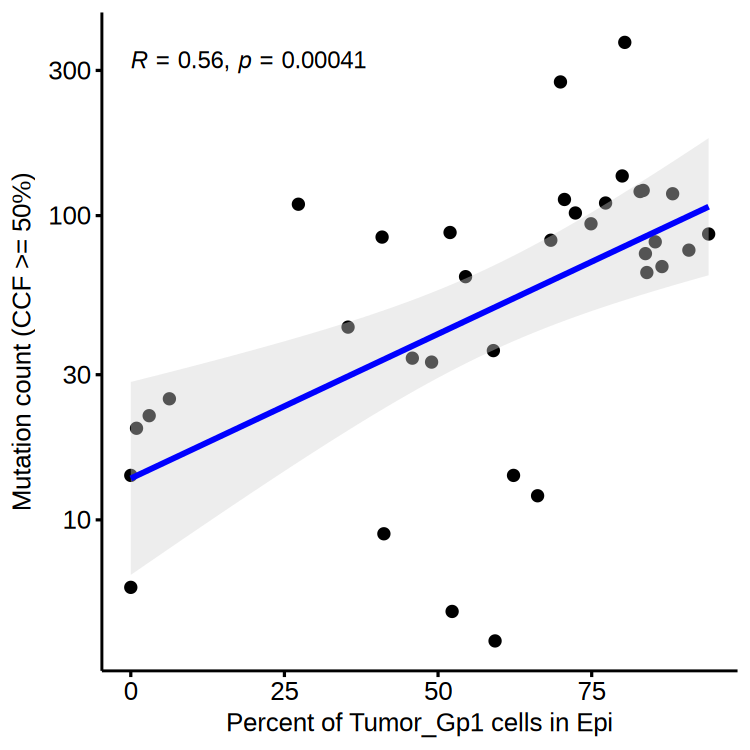

In [80]:
# Use all samples only
suf <- 'all'
dp <- df

loginfo('%s: %g samples', suf, length(unique(dp$sample_id)))

p <- ggscatter(
    data = dp,
    x = 'ek_pct_in_epi',
    y = 'n_mut_per_samp_ctype',
    conf.int = TRUE,
    add = 'reg.line',
    add.params = list(color = 'blue', fill = 'lightgray'),
    cor.coef = TRUE,
    cor.coeff.args = list(method = 'pearson')
) +
    scale_y_log10() +
    labs(
        x = 'Percent of Tumor_Gp1 cells in Epi',
        y = 'Mutation count (CCF >= 50%)'
    )

ggsave(
    filename = str_glue(
        '{outdir}/fig2i-scatter-ek_pct-vs-tmb_ccf_gt_0.5-tn_pair-fresh-t-{suf}.pdf'
    ),
    plot = p,
    width = 4,
    height = 4
)

# 在当前 notebook 中显示
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
p

## 2j: immune related cell communication

- desc: only T cells relevant pairs; T cells as target (exclude Epi_normal/mixture); use sample by sample results

In [81]:
f_full <- '../data/Figure2/stage4/a21_cell_comm/ek_hk_major/analysis/v2-interactions-with_clin-full.tsv'
f_interset <- '../data/Figure2/stage4/a21_cell_comm/immune_related_lg_cellchat_merge.tsv'
ctype_color <- c(
    'B & Plasma' = '#e71818', 'Tumor_Gp1' = '#317dbd', 'Endothelial' = '#46ae46',
    'Fibroblast' = '#9c4da5', 'Tumor_Gp2' = '#f79600', 'Myeloid' = '#f782bd', 'T cells' = '#bd9ece'
)

min_cell <- 50  # ligand/receptor should expressed in min_cell source/target cells
min_sample_num <- 3  # interaction should detected in these samples intra sample group
thresh <- 0.05  # significant threshold

### preprocess

In [82]:
# all results  
df_raw <- read_tsv(f_full, show_col_types = F) %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'),
           response = case_match(mandard_group, 'good' ~ 'R', 'poor' ~ 'NR')) %>% 
    select(-c('mandard_group')) %>%
    mutate(source = case_match(source, 'EK_tumor' ~ 'Tumor_Gp1', 'HK_tumor' ~ 'Tumor_Gp2', .default = source),
           target = case_match(target, 'EK_tumor' ~ 'Tumor_Gp1', 'HK_tumor' ~ 'Tumor_Gp2', .default = target))
loginfo('total %g interactions, %g samples', nrow(df_raw), length(unique(df_raw$sample)))

# interested cell-cell interactions
df_comm <- read_tsv(f_interset, show_col_types = F) %>% 
    filter(gene_type == 'receptor') %>% 
    select(interaction_name, immune_direction) %>% 
    distinct() 
loginfo('%g intersted interactions', nrow(df_comm))

2026-07-17 22:48:02.048412 INFO::total 251965 interactions, 81 samples
2026-07-17 22:48:02.069875 INFO::65 intersted interactions


In [83]:
# only T cells relevant L-R pairs
df <- df_raw %>% 
    filter(target == 'T cells',
           !source %in% c('Epi_Norm', 'Epi_Others'))
loginfo('%g T cells relevant pairs, %g samples', nrow(df), length(unique(df$sample)))

# filter by cell number
df <- df %>% 
    filter(n_cell_receptor_in_target_max >= min_cell, 
           n_cell_ligand_in_source_max >= min_cell)
loginfo('filter by cell number >= %g: %g records, %g samples',
        min_cell, nrow(df), length(unique(df$sample)))

# only intersted interactions
df <- merge(df, df_comm, by = 'interaction_name')
loginfo('only intersted interactions: %g records, %g samples', nrow(df), length(unique(df$sample)))

# only samples with clinical info
df_flt <- df %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]])
loginfo('samples with %s info: %g pairs, %g samples', gp, nrow(df_flt), length(unique(df_flt$sample)))

# filter by sample number
df_flt <- df_flt %>% 
    add_count(.data[[gp]], sample_type, source, target, interaction_name, name = 'n_sample') %>% 
    filter(n_sample >= min_sample_num)
loginfo('filter by sample number >= %g: %g records, %g samples',
        min_sample_num, nrow(df_flt), length(unique(df_flt$sample)))

# filter in-significant interactions
df_flt <- df_flt %>%
    summarise(.by = c(gp, 'sample_type', 'source', 'target', 'interaction_name'),
              p_min = min(pval)) %>%
    filter(p_min <= thresh) %>%
    select(.data[[gp]], sample_type, source, target, interaction_name) %>%
    merge(df_flt, by = c(gp, 'sample_type', 'source', 'target', 'interaction_name'))
loginfo('filter out interactions all insignificant intra sample group: %g records, %g samples',
        nrow(df_flt), length(unique(df_flt$sample)))

2026-07-17 22:48:02.108236 INFO::16885 T cells relevant pairs, 81 samples
2026-07-17 22:48:02.116103 INFO::filter by cell number >= 50: 14965 records, 81 samples
2026-07-17 22:48:02.124983 INFO::only intersted interactions: 996 records, 73 samples
2026-07-17 22:48:02.12991 INFO::samples with response info: 799 pairs, 62 samples
2026-07-17 22:48:02.141517 INFO::filter by sample number >= 3: 707 records, 62 samples
2026-07-17 22:48:02.166012 INFO::filter out interactions all insignificant intra sample group: 707 records, 62 samples


In [84]:
# init node info
df_node <- data.frame(name = sort(unique(c(df_flt$source, df_flt$target))))
df_node$node_color <- NA
for (nm in names(ctype_color)) {
    df_node$node_color[df_node$name == nm] <- ctype_color[nm]
}

# init edges
df_edge <- df_flt %>% 
    summarise(.by = c(.data[[gp]], sample_type, 'source', 'target', 'interaction_name', 'immune_direction'),
              prob_agg = mean(prob)) %>%  # summarise for samples of each interaction
    add_count(.data[[gp]], sample_type, source, target, immune_direction, name = 'n_interaction') %>% 
    summarise(.by = c(gp, 'sample_type', 'source', 'target', 'n_interaction', 'immune_direction'),
              prob_mean = mean(prob_agg),
              prob_med = median(prob_agg)) # summarise for interaction 
# add edge color (color by source)
df_edge <- df_node %>% 
    select(source = name, edge_color = node_color) %>% 
    merge(df_edge, by = 'source') %>% 
    select(source, target, edge_color, n_interaction, prob_mean, prob_med, .data[[gp]], sample_type, immune_direction)

df_node %>% write_tsv(str_glue('{outdir}/fig2j-t_immune-node.tsv'))
df_edge %>% write_tsv(str_glue('{outdir}/fig2j-t_immune-edge.tsv'))

### vlz

In [85]:
coords <- as.matrix(data.frame(
    c(1.0000000, -0.2225209, -0.9009689, -0.9009689, -0.2225209, 0.6234898, 0.6234898),
    c(0.0000000, -0.9749279, 0.4338837, -0.4338837, 0.9749279, 0.7818315, -0.7818315)
))

In [86]:
# weight by prob
weight_by <- 'prob_mean'
jp_opt(wd=14, hg = 6, res = 200)
pdf(file = str_glue('{outdir}/fig2j-t_immune-prob.pdf'), width = 14, height = 6)
par(mfrow = c(2, 4), mar = c(1.5, 0, 1.5, 0.5))
for (d in unique(df_edge$immune_direction)) {
    for (stype in c('pre', 'post')) {
        for (my_gp in gp_lvls[[gp]]) {
            dp_edge <- filter(df_edge, .data[[gp]] == my_gp, sample_type == stype, immune_direction == d)
            if (nrow(dp_edge) == 0) {
                plot.new()
                next
            }
            # plot
            net <- graph_from_data_frame(d = dp_edge, vertices = df_node, directed = T)
            plot(net, 
                 edge.arrow.size = 0.5, 
                 edge.curved = 0.4,
                 edge.color = E(net)$edge_color,
                 edge.width = get.edge.attribute(net, weight_by) * 300,
                 edge.label = round(get.edge.attribute(net, weight_by) * 100, 1),
                 edge.label.cex = 1,
                 vertex.size = 30,
                 vertex.color = V(net)$node_color,
                 vertex.label.color = "black",
                 vertex.label.cex = 1,
                 layout = coords,
                 main = str_glue('T cells {d} incoming signals in {my_gp}-{stype}'))
        }
    }
}
fig2j_immune_plot <- recordPlot()
dev.off()
# 在当前 notebook 中显示保存的图。
replayPlot(fig2j_immune_plot)

agg_record_814461054 
                   2

## Figure 2k: ECGEA survival analysis

# Figure 2k ECGEA survival plotting code\n\nOrganized copy. Inputs are in `../data/Figure2/Fig2k/`.\n

In [87]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.1 LTS

Matrix products: default
BLAS/LAPACK: /nfs_beijing_ai/zhaoren/work/260717_ESCC/.conda/envs/escc-repro-r43/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] grid      tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] survMisc_0.5.6        survminer_0.5.1       survival_3.8-3       
 [4] data.table_1.17.8     ComplexHeatmap_2.18.0 Seurat_5.3.0         
 [7] SeuratObject_5.2.0    sp_2.2-0              ggraph_2.2.1         
[10] igraph_2

In [88]:
require(data.table)
library(survival)
library(survminer)
library(survMisc)

In [89]:
#clinical_info$OS.time1 0:living 1:dead

clinical_info=fread("../data/Figure2/Fig2k/Survival_tbl.csv",sep=",",data.table=F)
clinical_info$sample=gsub("X","",clinical_info$sample)
clinical_info$sample <- sprintf("%03d", as.numeric(clinical_info$sample))
clinical_info$sample_t=paste0(clinical_info$sample,"T")
clinical_info$sample_n=paste0(clinical_info$sample,"N")

clinical_info$EKmarker=NA

#load RNA tbl
gene_count=fread("../data/Figure2/Fig2k/gene_count_155.csv",sep=",",data.table=F)

#filtering genes
gene_id=gene_count$EnsemblGene_GeneSymbol

tmp=strsplit(gene_id,'_',fixed=TRUE)
split_num=rep(0, length(tmp))
for(i in 1:length(tmp)){
    split_num[i]=length(tmp[[i]])
}

# split num > 2 are all ribosome gene or strcuture rna
gene_count=gene_count[split_num==2,]
gene_id=gene_id[split_num==2]

gene_tbl=do.call('rbind', strsplit(gene_id,'_',fixed=TRUE))
gene_tbl=data.frame(gene_tbl)
colnames(gene_tbl)=c("Ensembl","Gene_id")

#matrix
gene_count$EnsemblGene_GeneSymbol=NULL
gene_count=as.matrix(gene_count)
gene_count=t(gene_count)
gene_count_tumor=gene_count[match(clinical_info$sample_t,rownames(gene_count)),]
gene_count_normal=gene_count[match(clinical_info$sample_n,rownames(gene_count)),]

gene_count_tumor=t(apply(gene_count_tumor,1,function(x){x*1000000/sum(x)}))

In [90]:
gene_pick=c("KRT6B","TP63") #"KRT6B","TP63" "EPCAM", #"EPCAM","KRT6B"
gene_counter_pick=c("MUC1","TGFB1") # ,"MUC1", "PTGES" , ,"KRT6B","MUC1" ,"TGFB1"

sample_id,overall_survival_days,event,marker
<chr>,<dbl>,<int>,<fct>
001,265,1,Gp2
002,1219,0,mix
003,1218,0,Gp2
004,1213,0,Gp1
006,456,1,Gp2
009,1207,0,mix
010,571,1,mix
011,1149,0,mix
012,1200,0,mix


comparison,n_total,n_Gp1,n_mix,n_Gp2,chi_square,degrees_of_freedom,p_value
<chr>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>
Gp1 vs mix vs Gp2,155,31,93,31,14.2356,2,0.0008105495


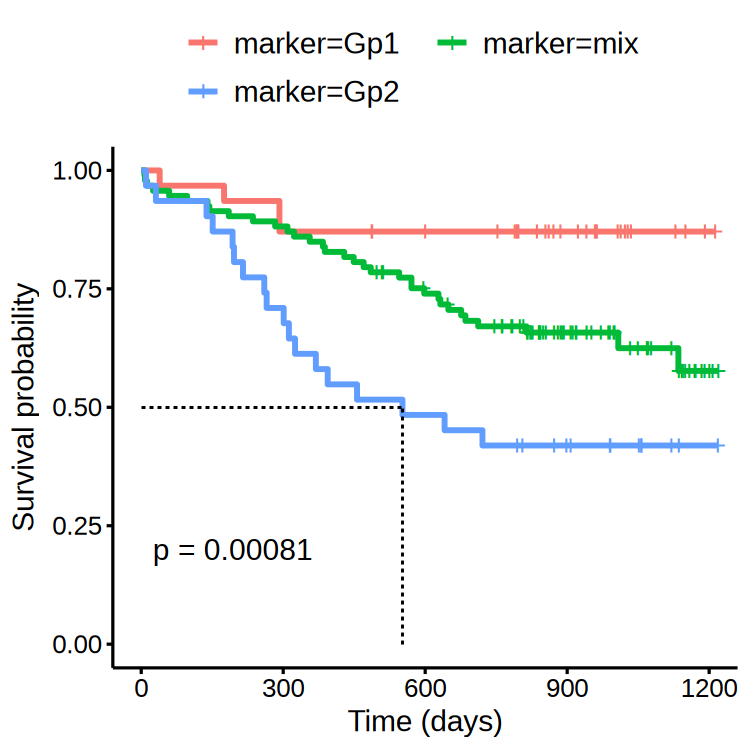

In [91]:
# Figure 2k: ECGEA survival analysis (final manuscript grouping: 20% / 60% / 20%)
# Recalculate the manuscript marker score directly from the input count matrix.
marker_mat <- gene_count_tumor[, gene_tbl$Gene_id %in% gene_pick, drop = FALSE]
counter_mat <- gene_count_tumor[, gene_tbl$Gene_id %in% gene_counter_pick, drop = FALSE]
stopifnot(ncol(marker_mat) == length(gene_pick), ncol(counter_mat) == length(gene_counter_pick))
value <- if (ncol(marker_mat) > 1) rowMeans(scale(marker_mat)) else as.numeric(marker_mat[, 1])
value <- if (ncol(counter_mat) > 1) value - rowMeans(scale(counter_mat)) else value - as.numeric(counter_mat[, 1])

clinical_info$marker <- ifelse(
    value > quantile(value, probs = 0.8), 'Gp1',
    ifelse(value < quantile(value, probs = 0.2), 'Gp2', 'mix')
)
clinical_info$marker <- factor(clinical_info$marker, levels = c('Gp1', 'mix', 'Gp2'))

# Patient-level data used directly by the Kaplan-Meier plot.
fig2k_plot_data <- clinical_info %>%
    transmute(
        sample_id = sample,
        overall_survival_days = as.numeric(OS),
        event = as.integer(OS.time1),
        marker = factor(as.character(marker), levels = c('Gp1', 'mix', 'Gp2'))
    ) %>%
    filter(
        !is.na(overall_survival_days),
        !is.na(event),
        !is.na(marker)
    )

core_fig2_dir <- '../resource_data/core_tables/Figure2'
create_dir(core_fig2_dir)
fig2k_plot_data %>%
    write_tsv(file.path(core_fig2_dir, 'Figure_2k_ECGEA_survival_marker_stratification.tsv'))

fit2 <- survfit(
    Surv(overall_survival_days, event) ~ marker,
    data = fig2k_plot_data
)

# Export the global three-group log-rank result shown by ggsurvplot().
fig2k_logrank <- survdiff(
    Surv(overall_survival_days, event) ~ marker,
    data = fig2k_plot_data
)
fig2k_logrank_stats <- tibble(
    comparison = 'Gp1 vs mix vs Gp2',
    n_total = nrow(fig2k_plot_data),
    n_Gp1 = sum(fig2k_plot_data$marker == 'Gp1'),
    n_mix = sum(fig2k_plot_data$marker == 'mix'),
    n_Gp2 = sum(fig2k_plot_data$marker == 'Gp2'),
    chi_square = unname(fig2k_logrank$chisq),
    degrees_of_freedom = length(fig2k_logrank$n) - 1L,
    p_value = pchisq(
        fig2k_logrank$chisq,
        df = length(fig2k_logrank$n) - 1L,
        lower.tail = FALSE
    )
)
fig2k_logrank_stats %>%
    write_tsv(file.path(core_fig2_dir, 'Figure_2k_ECGEA_logrank_statistics.tsv'))

fig2k_plot_data
fig2k_logrank_stats

p <- ggsurvplot(
    fit2,
    data = fig2k_plot_data,
    pval = TRUE,
    surv.median.line = 'hv'
)
p$plot <- p$plot +
    theme(
        legend.text = element_text(size = 14),
        legend.title = element_blank(),
        axis.text = element_text(size = 16)
    ) +
    labs(x = 'Time (days)') +
    guides(color = guide_legend(nrow = 2, byrow = TRUE))

ggsave(
    filename = str_glue('{outdir}/fig2k-ECGEA_survival-Gp1_mix_Gp2.pdf'),
    plot = p$plot,
    width = 5,
    height = 4
)

# 在当前 notebook 中显示最后生成的图。
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)
print(p)


## 2l: Tumor_Gp1 change within the NR group

min 50 Epi cells per sample

In [92]:
min_cell <- 50
df <- read_tsv(str_glue('{outdir}/fig2h-cell_comp-ek_hk.tsv'), show_col_types = F) %>% 
    filter(cell_type == 'Tumor_Gp1')
df %>% dim

[1] 81  9

In [93]:
df[1:5,]

patient,patient_id,response,sample,sample_type,cell_type,pct,n_cell_samp,n_cell_per_sample_ctype
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
P01,025,R,P01-Treat,post,Tumor_Gp1,60.70234,7478,1196
P01,025,R,P01-Baseline,pre,Tumor_Gp1,40.52045,10404,1076
P02,026,NA,P02-Baseline,pre,Tumor_Gp1,31.55556,8359,225
P03,028,NR,P03-Treat,post,Tumor_Gp1,8.90411,11843,292
P03,028,NR,P03-Baseline,pre,Tumor_Gp1,62.28070,4580,114


      
       Gp1- Gp1+ NR  R <NA>
  NR      8    5  6  0    0
  R       0    0  0 32    0
  <NA>    0    0  0  0   19

# A tibble: 2 × 13
  group1   group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>    <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 Gp1--pre Gp1--…                1 FALSE      8     7      NA          45 0.0541
2 Gp1+-pre Gp1+-…                2 FALSE      5     5      NA           5 0.151 
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


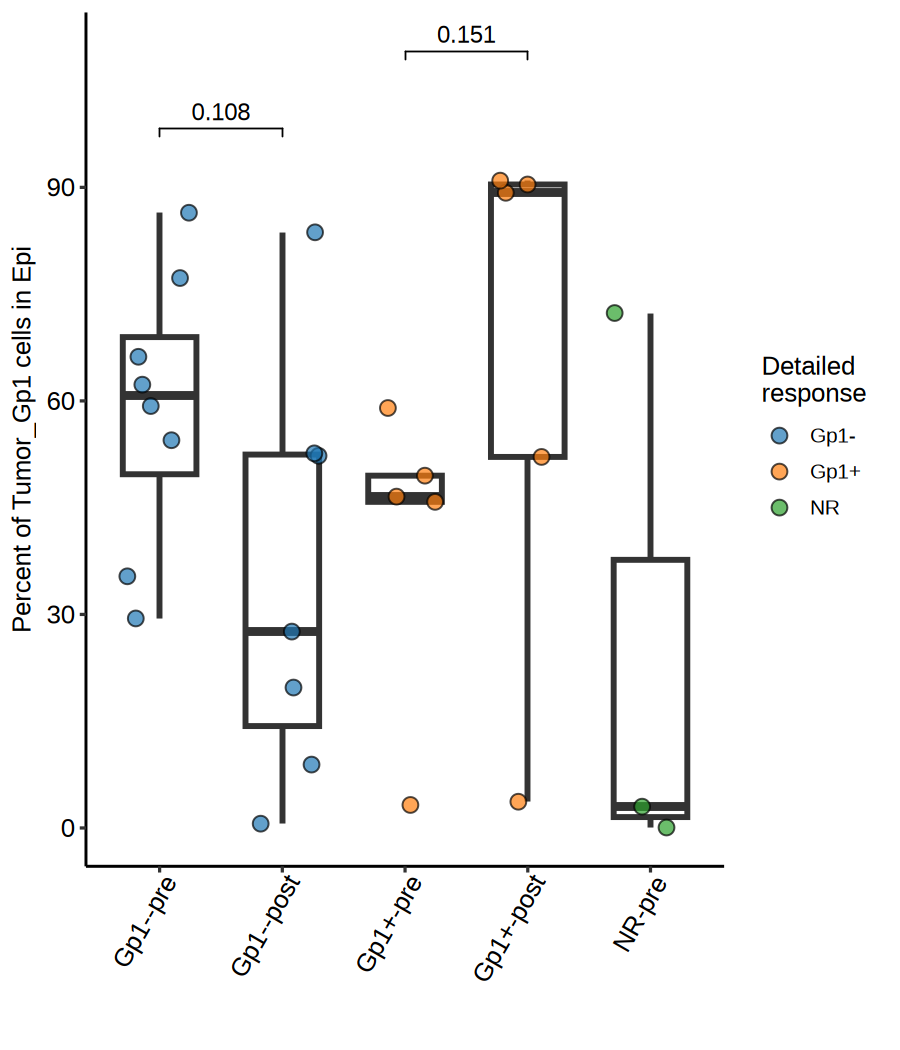

In [94]:
# Redefine patient groups
cc_diff <- df %>%
    pivot_wider(
        id_cols = c('patient', all_of(gp)),
        names_from = 'sample_type',
        values_from = 'pct'
    ) %>%
    filter(!is.na(pre), !is.na(post)) %>%
    mutate(diff = post - pre)

pat_pEKI <- cc_diff %>%
    filter(.data[[gp]] == 'NR', diff > 0) %>%
    pull(patient)

pat_pEKD <- cc_diff %>%
    filter(.data[[gp]] == 'NR', diff < 0) %>%
    pull(patient)

df_gp <- read_tsv(f_pat_gp, show_col_types = FALSE) %>%
    mutate(
        response_v2 = case_when(
            patient %in% pat_pEKD ~ 'Gp1-',
            patient %in% pat_pEKI ~ 'Gp1+',
            TRUE ~ .data[[gp]]
        )
    )

# Update clinical information
df_gp %>%
    write_tsv('../output/patient_info_v2.tsv')

table(
    df_gp[[gp]],
    df_gp$response_v2,
    useNA = 'ifany'
)

# Update cell composition
df <- add_clin_info(
    df = df,
    ftsv = '../output/patient_info_v2.tsv',
    columns = 'response_v2',
    merge_by = 'patient'
)

df %>%
    write_tsv(str_glue('{outdir}/fig2l-cell_comp-ek.tsv'))

# Plot min50 samples only. R-pre and R-post are intentionally excluded.
curr_gp <- 'response_v2'
fig2l_comparisons <- list(
    c('Gp1--pre', 'Gp1--post'),
    c('Gp1+-pre', 'Gp1+-post')
)
fig2l_xorder <- c(
    'Gp1--pre', 'Gp1--post',
    'Gp1+-pre', 'Gp1+-post',
    'NR-pre'
)
fig2l_fill_order <- c('Gp1-', 'Gp1+', 'NR')

fig2l_plot_data <- read_tsv(
    str_glue('{outdir}/fig2l-cell_comp-ek.tsv'),
    show_col_types = FALSE
) %>%
    filter(
        n_cell_per_sample_ctype >= min_cell,
        .data[[curr_gp]] %in% fig2l_fill_order,
        paste(.data[[curr_gp]], sample_type, sep = '-') %in% fig2l_xorder
    )

p <- fig2l_plot_data %>%
    cell_comp_boxplot(
        x = c(curr_gp, 'sample_type'),
        y = 'pct',
        facet_by = NULL,
        pt_fill = curr_gp,
        pair_by = NULL,
        xorder = fig2l_xorder,
        fill_order = fig2l_fill_order,
        xangle = 60
    ) +
    labs(
        y = 'Percent of Tumor_Gp1 cells in Epi',
        fill = 'Detailed\nresponse'
    ) +
    theme(legend.position = 'right')

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'pct',
    comparisons = fig2l_comparisons,
    use_paired = FALSE,
    apply_correction = TRUE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue(
        '{outdir}/fig2l-box_cc_in_epi-macrotype-{curr_gp}-min{min_cell}.pdf'
    ),
    plot = p,
    width = 5,
    height = 6
)

# Display in the current notebook
options(repr.plot.width = 6, repr.plot.height = 7, repr.plot.res = 150)
p


## 2m: Treg expaned percent boxplot: min10 result

- percent in T cells (RNA & TCR data), n_cell_per_sample_subtype >= 10, by response-v2
- 2024-02-27: now is fig2m

In [95]:
f_expand <- '../data/Figure2/stage4/a03_tcr/expansion/expand_cell_pct.csv'
f_pat_gp_v2 <- '../data/Figure2/tables/patient_info_v2.tsv'
min_cell <- 10
valid_types <- c('Treg_LTB', 'Treg_TNFRSF4')

df <- read_csv(file = f_expand, show_col_types = F) %>%
    filter(subtype %in% valid_types) %>%
    mutate(sample = paste(patient, sample_type, sep = '-')) %>%
    select(sample, sample_type, patient, subtype, n_expand_cell_per_sample_stype, n_cell_per_sample_subtype, pct_by_subtype) %>%
    add_clin_info(ftsv = f_pat_gp_v2, columns = NULL, merge_by = 'patient') %>%
    mutate(macrotype = 'Treg') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
loginfo('Treg: %g records, %g samples', nrow(df), length(unique(df$sample)))

write_tsv(x = df, file = str_glue('{outdir}/fig2m-Treg_expand_percet-by_subtype.tsv'))

2026-07-17 22:48:09.321466 INFO::Treg: 160 records, 81 samples


In [96]:
df %>% filter(n_cell_per_sample_subtype < 10) %>% count(sample, response_v2)

sample,response_v2,n
<chr>,<chr>,<int>
P01-Treat,R,2
P13-Treat,Gp1-,1
P25-Treat,R,1
P43-Treat,R,2
P46-Treat,R,2
P51-Treat,R,1


2026-07-17 22:48:10.115289 INFO::all: 81 samples
# A tibble: 4 × 14
  subtype  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W
  <chr>    <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>
1 Treg_LTB R-pre  Gp1+-…                1 FALSE     22     5      NA        34.5
2 Treg_LTB R-post Gp1+-…                2 FALSE     19     5      NA        20  
3 Treg_TN… R-pre  Gp1+-…                1 FALSE     22     5      NA        29  
4 Treg_TN… R-post Gp1+-…                2 FALSE     18     5      NA        23  
# ℹ 5 more variables: p_raw <dbl>, p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


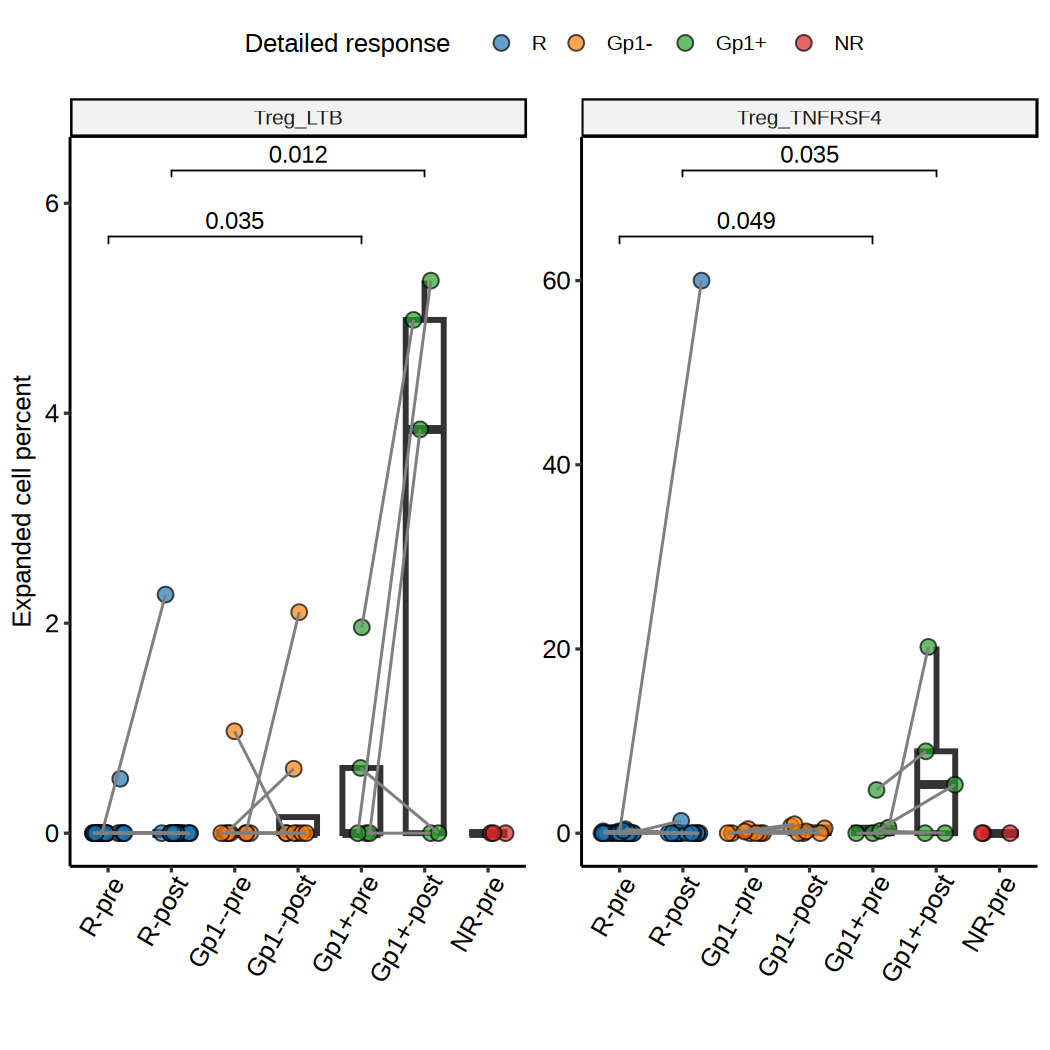

In [97]:

curr_gp <- 'response_v2'
suf <- 'all'

# 只进行以下两个比较
selected_comparisons <- list(
    c('R-pre',  'Gp1+-pre'),
    c('R-post', 'Gp1+-post')
)

dp <- df

loginfo(
    '%s: %g samples',
    suf,
    length(unique(dp$sample))
)

p <- dp %>%
    filter(.data[[curr_gp]] %in% gp_lvls[[curr_gp]]) %>%
    cell_comp_boxplot(
        x = c(curr_gp, 'sample_type'),
        y = 'pct_by_subtype',
        pt_fill = curr_gp,
        facet_by = 'subtype',
        xorder = comb_order_v2,
        fill_order = gp_lvls[[curr_gp]],
        ncol = 7,
        wrap_free = 'free',
        xangle = 60,
        ytitle = 'Expanded cell percent'
    ) +
    labs(fill = 'Detailed response')

p <- configure_panel_wilcox(
    p,
    x = 'plot_x',
    y = 'pct_by_subtype',
    comparisons = selected_comparisons,
    facet_by = 'subtype',
    use_paired = FALSE,
    apply_correction = TRUE,
    correction_method = 'BH'
)

panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)

ggsave(
    filename = str_glue(
        '{outdir}/fig2m-box_expand_in_subtype-detail-{curr_gp}-all.pdf'
    ),
    plot = p,
    width = 5,
    height = 6
)

# 在当前 notebook 中显示
options(
    repr.plot.width = 7,
    repr.plot.height = 7,
    repr.plot.res = 150
)

p

## 2n-o: virus cell percent

- date: 2024-02-27

### 2n: pct in all cells, R-pre vs NR-pre 

In [98]:
f_obs <- '../data/Figure2/stage4/a24_microbe/domain_lvl/whole_obs_with_domain_logrpm.rds'
min_cell <- 50
cutoff <- 0

In [99]:
df <- harmonize_nr_labels(readRDS(f_obs)) %>% 
    mutate(bi_type = case_when(
        is.na(Viruses) ~ NA_character_,
        Viruses > cutoff ~ 'Virus-detected',
        Viruses <= cutoff ~ 'Non-detected',
        TRUE ~ 'others'
    )) %>%
    count(sample, bi_type, name = 'n_cell') %>%
    add_count(sample, wt = n_cell, name = 'n_cell_per_sample') %>%
    filter(n_cell_per_sample >= min_cell) %>%
    mutate(pct = 100 * n_cell / n_cell_per_sample) %>%
    pivot_wider(id_cols = c('sample'), 
                names_from = 'bi_type', values_from = 'pct', values_fill = 0) %>%
    separate(col = 'sample', into = c('patient', 'sample_type'), sep = '-', remove = F) %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
loginfo('%g records', nrow(df))
df %>% write_tsv(str_glue('{outdir}/fig2n-virus_detection_in_whole-bi-sample_lvl-pct.tsv'))

2026-07-17 22:48:16.296664 INFO::81 records


# A tibble: 1 × 13
  group1 group2 comparison_order paired    n1    n2 n_pairs statistic_W  p_raw
  <chr>  <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>  <dbl>
1 R-pre  NR-pre                1 FALSE     22    16      NA         243 0.0484
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


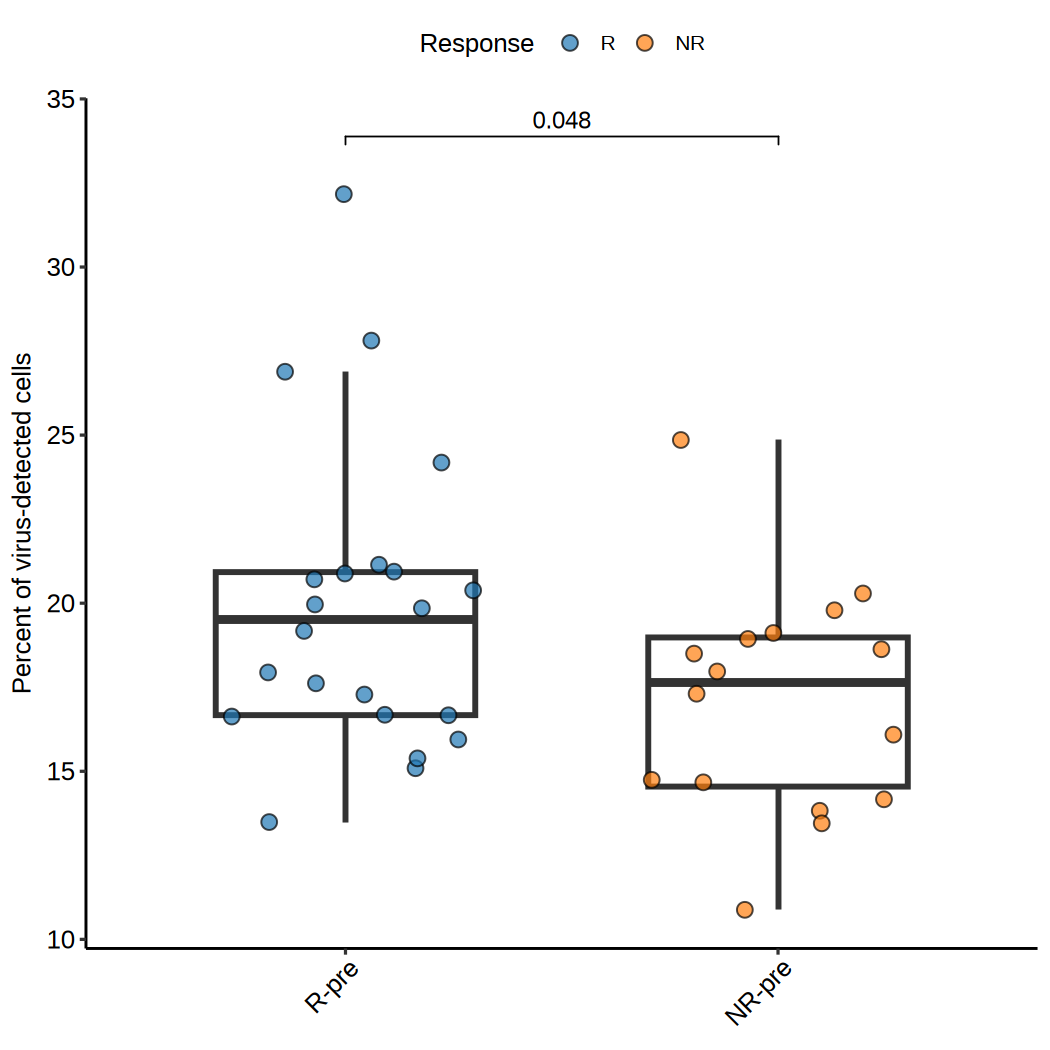

In [100]:

p <- read_tsv(str_glue('{outdir}/fig2n-virus_detection_in_whole-bi-sample_lvl-pct.tsv'), show_col_types = F) %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    filter(sample_type == 'pre') %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'Virus-detected', pt_fill = gp, pair_by = NULL, 
                      xorder = comb_order, fill_order = gp_lvls[[gp]], facet_by = NULL, ncol = 3)  +
    labs(y = 'Percent of virus-detected cells', fill = 'Response') +
    theme(axis.title.x = element_blank())
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'Virus-detected',
    comparisons = list(c('R-pre', 'NR-pre')),
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2n-box_cell_pct-virus_detected_cells-whole.pdf'), width = 3, height = 6, plot = p)
# 在当前 notebook 中显示最后生成的图。
p


### 2o: pct in tumor Gp1/2 cells, Gp1 vs Gp2

In [101]:
f_obs <- '../data/Figure2/stage4/a24_microbe/domain_lvl/whole_obs_with_domain_logrpm.rds'
min_cell <- 50
cutoff <- 0

used_ctypes <- c('Tumor_Gp1', 'Tumor_Gp2')

In [102]:
# rename cell type
df <- harmonize_nr_labels(readRDS(f_obs)) %>% 
    filter(cell_type == 'Epithelial')

df$celltype <- df$subtype
for (nm in names(ctype_ls)) {
    df$celltype[df$subtype %in% ctype_ls[[nm]]] <- nm
}
# stat percent in each cluster
df_stat <- df %>% 
    mutate(bi_type = case_when(
        is.na(Viruses) ~ NA_character_,
        Viruses > cutoff ~ 'Virus-detected',
        Viruses <= cutoff ~ 'Non-detected',
        TRUE ~ 'others'
    )) %>%
    count(sample, celltype, bi_type, name = 'n_cell') %>%
    add_count(sample, celltype, wt = n_cell, name = 'n_cell_per_sample_ctype') %>%
    filter(n_cell_per_sample_ctype >= min_cell) %>%
    mutate(pct = 100 * n_cell / n_cell_per_sample_ctype) %>%
    pivot_wider(id_cols = c('sample', 'celltype'), 
                names_from = 'bi_type', values_from = 'pct', values_fill = 0) %>%
    separate(col = 'sample', into = c('patient', 'sample_type'), sep = '-', remove = F) %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df_stat %>% write_tsv(str_glue('{outdir}/fig2o-virus_detection_in_epi_group-bi-sample_lvl-pct.tsv'))

# A tibble: 1 × 13
  group1  group2 comparison_order paired    n1    n2 n_pairs statistic_W   p_raw
  <chr>   <chr>             <int> <lgl>  <int> <int>   <int>       <dbl>   <dbl>
1 Tumor_… Tumor…                1 FALSE     60    17      NA         726 0.00813
# ℹ 4 more variables: p_adj <dbl>, p_display <dbl>, label <chr>,
#   y.position <dbl>


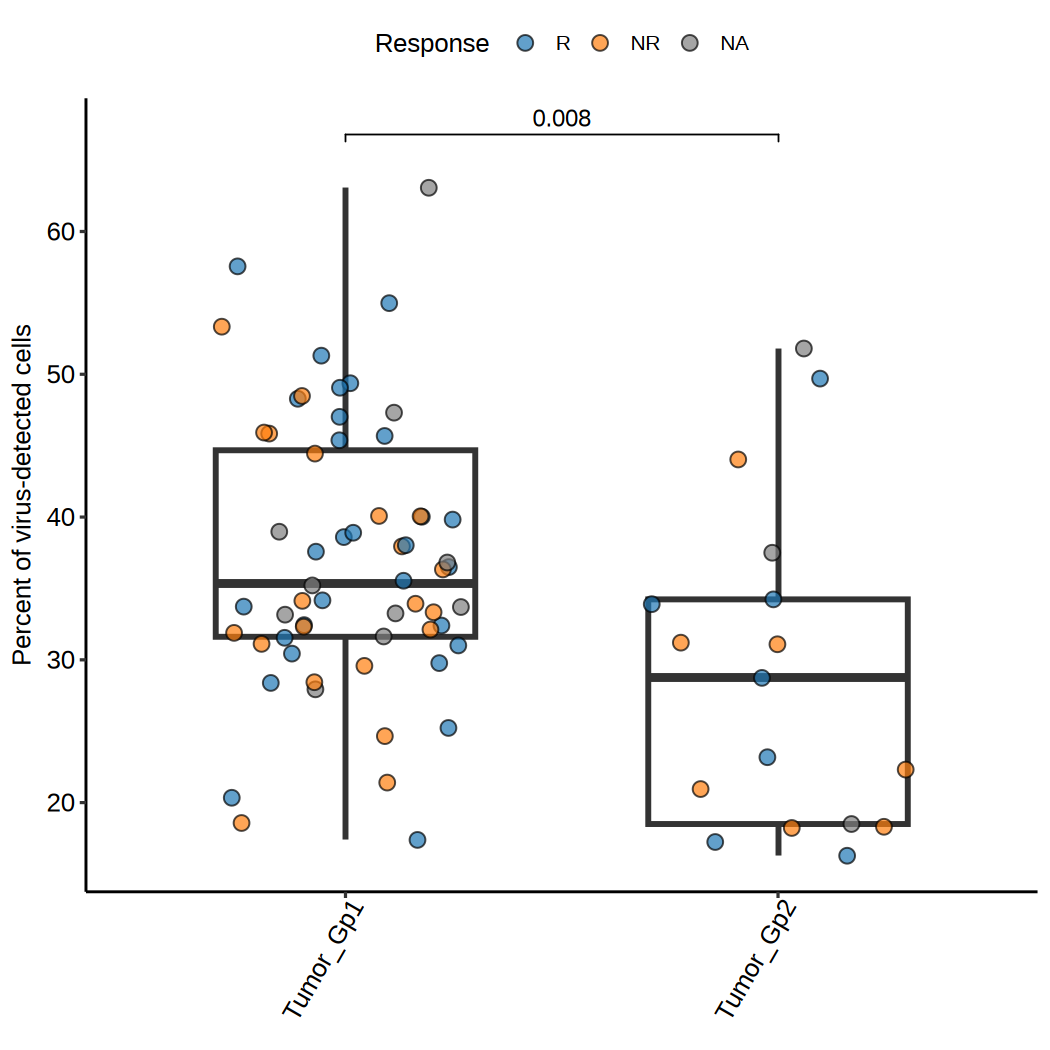

In [103]:

p <- read_tsv(str_glue('{outdir}/fig2o-virus_detection_in_epi_group-bi-sample_lvl-pct.tsv'), show_col_types = F) %>% 
    filter(celltype %in% c('Tumor_Gp1', 'Tumor_Gp2')) %>%
    mutate(celltype = factor(celltype, names(ctype_ls))) %>%
    cell_comp_boxplot(x = c('celltype'), y = 'Virus-detected', pt_fill = gp,
                      pair_by = NULL, facet_by = NULL, ncol = 3, xangle = 60,
                      xorder = names(ctype_ls), fill_order = gp_lvls[[gp]])  +
    labs(y = 'Percent of virus-detected cells', fill = 'Response') +
    theme(axis.title.x = element_blank())
p <- configure_panel_wilcox(
    p,
    x = 'plot_x', y = 'Virus-detected',
    comparisons = list(c('Tumor_Gp1', 'Tumor_Gp2')),
    apply_correction = FALSE,
    correction_method = 'BH'
)
panel_stats <- get_panel_wilcox_stats(p)
print(panel_stats, n = Inf)
ggsave(filename = str_glue('{outdir}/fig2o-box_cell_pct-virus_detected_cells-gp1_vs_gp2.pdf'), width = 3, height = 6, plot = p)
# 在当前 notebook 中显示最后生成的图。
p


## Export the final core resource data